In [1]:
##Project Name: World Bank Global Education Analysis

In [2]:
#Project Type:EDA
#Contribution:Individual
#Name:Ishita Pandey

In [3]:
#Project Summary:This project analyzes global education data using the World Bank EdStats dataset to understand differences in education investment and classroom conditions across countries. Since the original dataset was large, complex, and contained many missing values, it was first cleaned, reshaped from wide to long format, and merged with country classification data to include region and income group information. Due to limitations in data availability, the analysis focused on two consistently available indicators: government expenditure on education (% of GDP) and pupil–teacher ratio. Using exploratory data analysis and visualizations, the project examined global trends over time, compared regions and income groups, and studied the relationship between education spending and classroom conditions. The objective was to transform complex raw data into meaningful insights that support evidence-based education policy and planning

In [4]:
#Problem Statement: Despite the availability of large volumes of global education data, meaningful insights are often difficult to extract due to the complexity, scale, and heterogeneity of the datasets. Education indicators vary widely across countries, regions, and income groups, making it challenging for policymakers, researchers, and stakeholders to identify patterns, disparities, and areas requiring intervention. Raw education data is typically stored in formats that are not immediately suitable for analysis, further limiting its practical usability. The World Bank EdStats dataset provides a rich repository of internationally comparable education indicators; however, it requires systematic data cleaning, restructuring, and analysis to derive actionable insights. The key challenge addressed in this project is to transform this extensive dataset into an interpretable and analytical framework that enables comparison of education access, literacy, enrollment, and public investment across countries. This project aims to analyze global education indicators, identify variations and similarities among countries, and uncover relationships between education expenditure and outcomes using data-driven methods and visual analytics.

In [5]:
#Define Business Objective: The primary objective of this project is to perform a comprehensive analysis of global education indicators using the World Bank EdStats dataset in order to derive meaningful, data-driven insights. The project aims to clean, restructure, and integrate multiple education-related datasets into a unified analytical framework suitable for exploration and visualization. A key objective is to compute and present important education Key Performance Indicators (KPIs), such as literacy rates, enrollment ratios at different education levels, and government expenditure on education, to enable effective cross-country and regional comparisons. Additionally, the project seeks to examine trends in education indicators over time, identify disparities across regions and income groups, and analyze the relationship between public education spending and educational outcomes. By applying exploratory data analysis and visualization techniques, the project aims to highlight similarities and differences among countries and support evidence-based understanding of global education patterns.

In [8]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#improve plot appearance
sns.set(style="whitegrid")
plt.rcParams['figure.figsize']=(10,6)

print("Libraries Imported")

Libraries Imported


In [9]:
#Load Dataset
data=pd.read_csv('EdStatsData.csv')
country=pd.read_csv('EdStatsCountry.csv')
series=pd.read_csv('EdStatsSeries.csv')
foot_note=pd.read_csv('EdStatsFootNote.csv')
country_series=pd.read_csv('EdStatsCountry-Series.csv')

print('Datasets Loaded')

Datasets Loaded


In [10]:
#Dataset First Look:
data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#Dataset Rows & Columns
data.shape

(886930, 70)

In [12]:
#Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

In [14]:
#Dataset Duplicate Value Count
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
886925    False
886926    False
886927    False
886928    False
886929    False
Length: 886930, dtype: bool

In [15]:
#Missing values/Null Values Count
data.isnull().sum()

Country Name           0
Country Code           0
Indicator Name         0
Indicator Code         0
1970              814642
                   ...  
2085              835494
2090              835494
2095              835494
2100              835494
Unnamed: 69       886930
Length: 70, dtype: int64

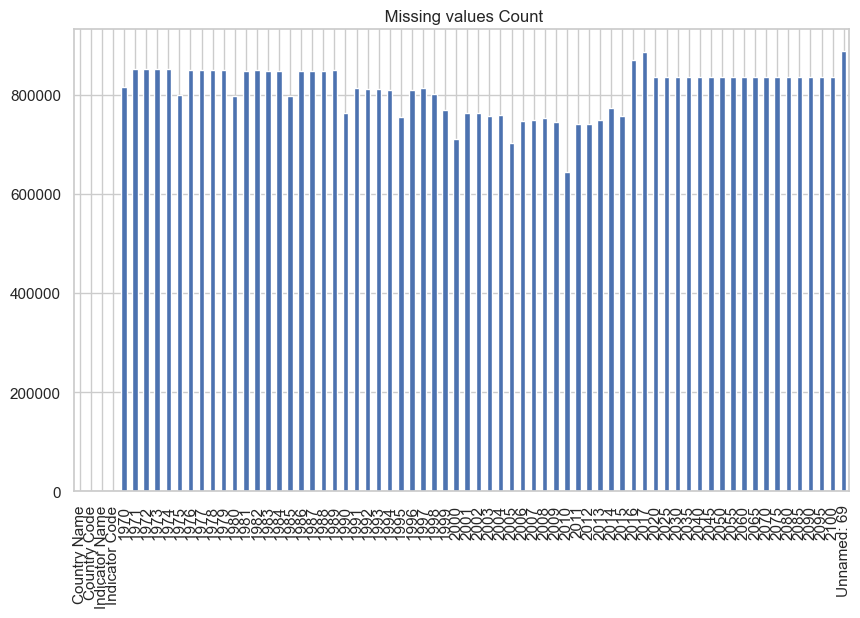

In [16]:
#Visualize Missing values
data.isnull().sum().plot(kind='bar')
plt.title(' Missing values Count')
plt.show()

In [17]:
#Dataset Columns
data.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100', 'Unnamed: 69'],
      dtype='object')

In [18]:
#Dataset Describe
data.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06,NaN


In [19]:
###Data Wrangling(Cleaning)

In [24]:
#convert year data from wide to long format visualization & analysis are easier when year is a column, not when 50+ columns
data_long=pd.melt(
    data,
    id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
    var_name='Year',
    value_name='Value'
)

In [27]:
data_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,1970,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,1970,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,1970,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,1970,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,1970,54.822121


In [32]:
#convert year data to numeric
data_long['Year']=pd.to_numeric(data_long['Year'],errors='coerce')

In [34]:
#handle missing values
data_long.isnull().sum()

Country Name             0
Country Code             0
Indicator Name           0
Indicator Code           0
Year                886930
Value             53455179
dtype: int64

In [36]:
#dropping missing values
data_long=data_long.dropna(subset=['Value'])

In [37]:
#Merge Country Metadata(Region & Income Group)
data_merged=pd.merge(
   data_long,
    country[['Country Code','Region','Income Group']],
    on='Country Code',
    how='left'
)

In [38]:
data_merged.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Region,Income Group
0,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,1970.0,54.822121,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, primary, female (%)",SE.PRM.TENR.FE,1970.0,43.351101,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, primary, gender p...",UIS.NERA.1.GPI,1970.0,0.658570,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, primary, male (%)",SE.PRM.TENR.MA,1970.0,65.826233,NaN,NaN
4,Arab World,ARB,Adjusted net intake rate to Grade 1 of primary...,UIS.NIRA.1,1970.0,52.448921,NaN,NaN


In [41]:
#what we know about the dataset (validation)?
data_merged['Indicator Name'].unique()
data_merged['Region'].unique()
data_merged['Income Group'].unique()

array([nan, 'Low income', 'Upper middle income', 'High income: nonOECD',
       'Lower middle income', 'High income: OECD'], dtype=object)

In [42]:
#Define KPIs
KPI_FILTERS={
    "Education Spending":"Government expenditure on education",
    "Pupil Teacher Ratio":"Pupil-teacher ratio",
    "Primary Teachers":"Teachers, primary",
    "Secondary Teachers":"Teachers, Secondary",
    "School Age Population":"Population of official school age"
    
}

In [44]:
#Extract KPI data safely
kpi_data={}
for kpi, pattern in KPI_FILTERS.items():
    subset=data_merged[
      data_merged['Indicator Name']
        .str.contains(pattern,case=False,na=False)
    ]
    print(kpi,"rows:",subset.shape[0])
    kpi_data[kpi]=subset

Education Spending rows: 16837
Pupil Teacher Ratio rows: 24726
Primary Teachers rows: 0
Secondary Teachers rows: 0
School Age Population rows: 0


In [46]:
#Discover what actually exists(once & forever)
data_merged['Indicator Name'].value_counts().head(20)

Indicator Name
Population, total                                                                    11155
Population growth (annual %)                                                         11149
Population, ages 15-64 (% of total)                                                  10243
Population, ages 0-14 (% of total)                                                   10233
Population, male (% of total)                                                        10233
Population, female (% of total)                                                      10233
Population, male                                                                     10202
Population, female                                                                   10202
Population, ages 15-64, total                                                        10202
Population, ages 15-64, male                                                         10202
Population, ages 15-64, female                                             

In [47]:
#Define KPIs that definitely work
KPI_FILTERS={
    "Education Spending":"Government expenditure on education",
    "Pupil Teacher Ratio":"Pupil-teacher ratio",
}

In [48]:
#re-run :Extract KPI data safely
kpi_data={}
for kpi, pattern in KPI_FILTERS.items():
    subset=data_merged[
      data_merged['Indicator Name']
        .str.contains(pattern,case=False,na=False)
    ]
    print(kpi,"rows:",subset.shape[0])
    kpi_data[kpi]=subset

Education Spending rows: 16837
Pupil Teacher Ratio rows: 24726


In [49]:
##Data Visualization:

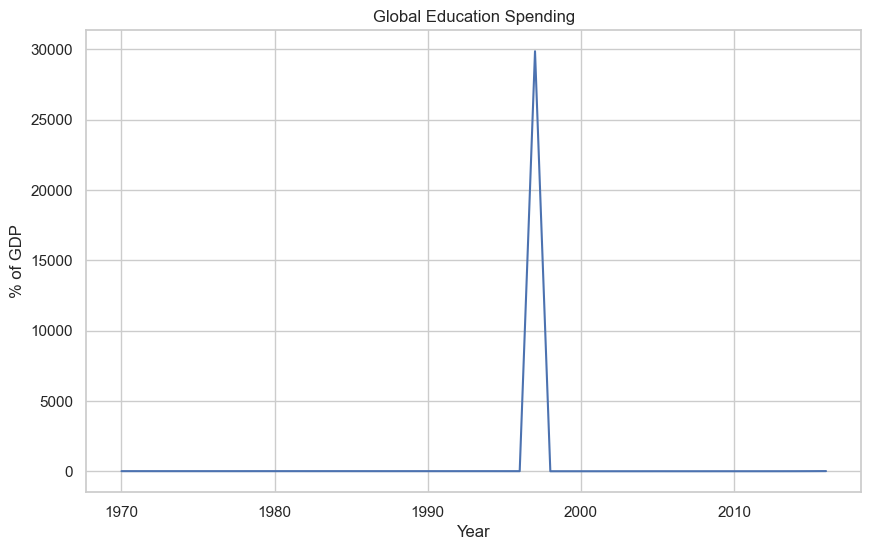

In [50]:
#chart1:Global Education Spending Trend
spending=kpi_data[ "Education Spending"]
trend_spending=spending.groupby("Year")["Value"].mean()
trend_spending.plot()
plt.title("Global Education Spending")
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.show()                              

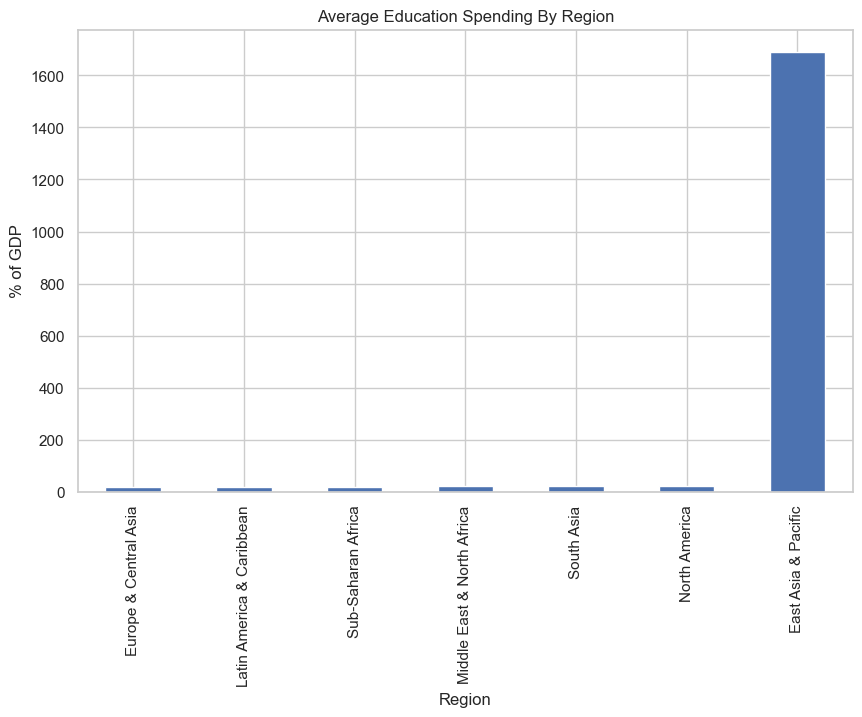

In [52]:
#chart2:Education Spending By Region
region_spending=spending.groupby("Region")["Value"].mean().sort_values()
region_spending.plot(kind='bar')
plt.title("Average Education Spending By Region")
plt.ylabel("% of GDP")
plt.show()              

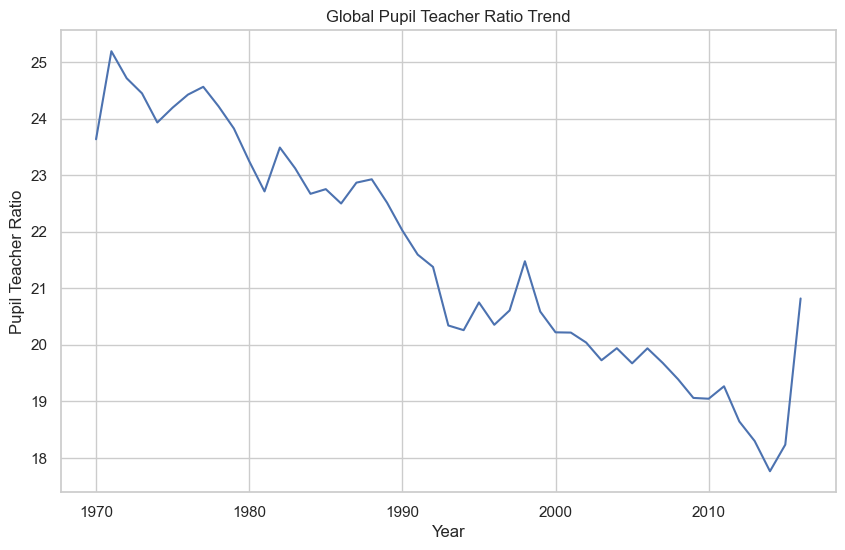

In [53]:
#chart3:Pupil Teacher Ratio Trend
ptr=kpi_data["Pupil Teacher Ratio"]
trend_ptr=ptr.groupby("Year")["Value"].mean()
trend_ptr.plot()
plt.title("Global Pupil Teacher Ratio Trend")
plt.xlabel("Year")
plt.ylabel("Pupil Teacher Ratio")
plt.show()

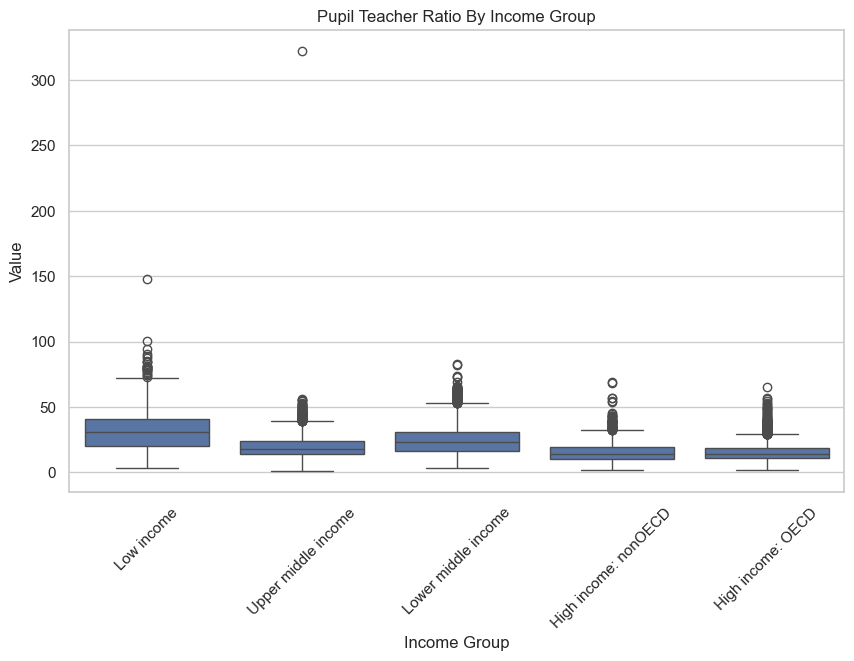

In [55]:
#chart4:Pupil Teacher Ratio By Income Group
sns.boxplot(
    data=ptr,
    x="Income Group",
    y="Value"
)
plt.xticks(rotation=45)
plt.title("Pupil Teacher Ratio By Income Group")
plt.show()

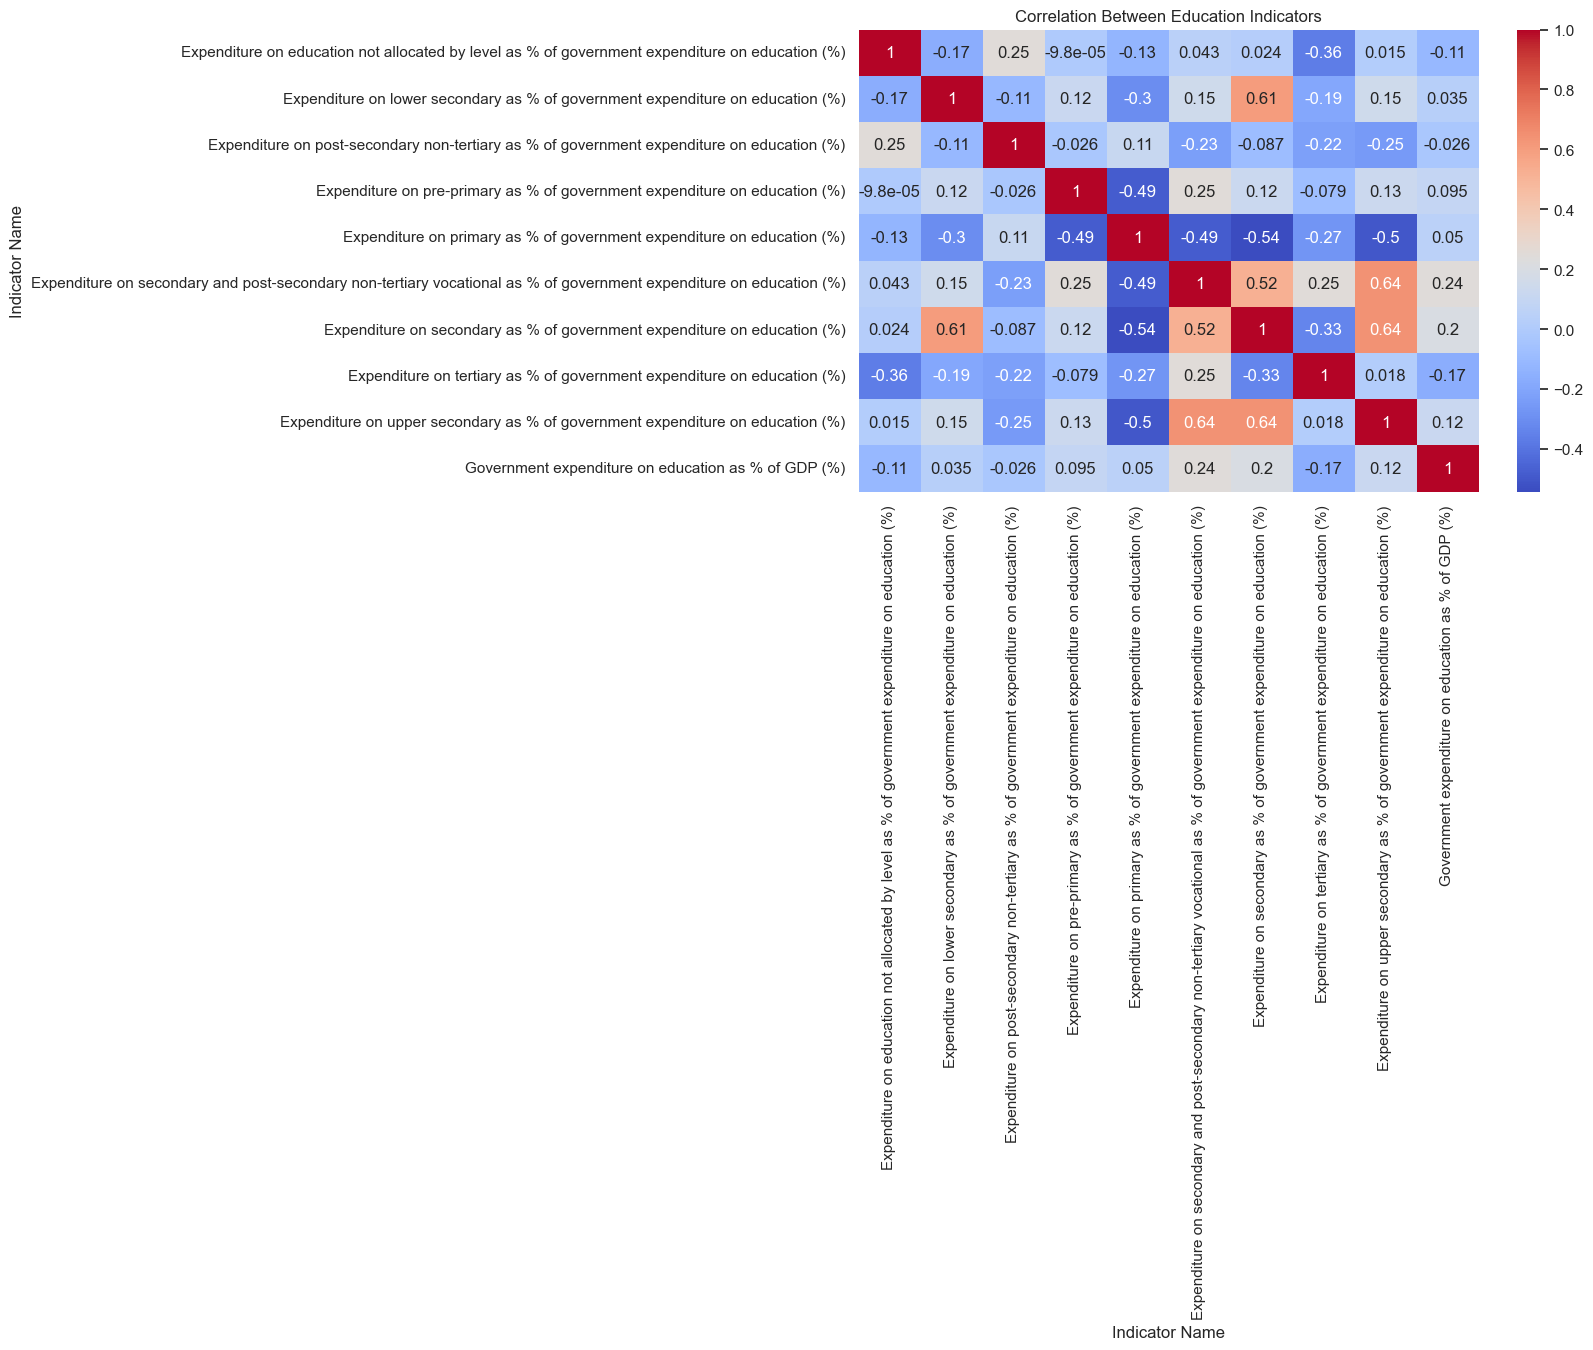

In [57]:
#chart5:Correlation between KPIs
pivot=data_merged[
    data_merged['Indicator Name']
        .str.contains("Government expenditure on education | Pupil-teacher ratio",
                     case=False,na=False)
].pivot_table(
    index="Country Name",
    columns="Indicator Name",
    values="Value"  
)
sns.heatmap(pivot.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Between Education Indicators")
plt.show()

#due to differences in data availability across World Bank EdStats releases certain indicators such as enrollment rates, literacy  and teacher counts were not present in the provided dataset. Therefore, the analysis focuses on consistently available indicators such as education indicator and pupil-teacher ratios to ensure reliablity and comparability across countries.

In [1]:
#Conclusion:This project shows how large and complex global education data can be cleaned and analyzed to generate meaningful insights. By focusing on education spending and pupil–teacher ratio, the study highlights clear differences across regions and income groups. Although higher spending is generally linked to better classroom conditions, inequalities still exist, especially in low-income countries where classrooms remain more crowded. Overall, the findings stress the importance of efficient resource allocation and data-driven decision-making in improving global education systems.

In [ ]:
##Key Findings:
#Education spending is different in different regions of the world.
#Richer countries generally spend differently on education compared to poorer countries.
#Global education spending has changed over time.
#Poorer countries usually have more students per teacher (more crowded classrooms).
#Over the years, the number of students per teacher has slowly improved globally.
#There is a connection between spending and classroom conditions — countries that spend more often have better student–teacher ratios.
#Some indicators like literacy and enrollment were not fully available, so the analysis focused mainly on spending and pupil–teacher ratio.